# Snapshot methods: decide what remembers

**Mirror scope:** visible GCN-GRU, released EvolveGCN H/O, complete trainers and authenticated data. Short execution is a full-data daily course fit plus a full-data SBM pilot; named full runs are separately gated. Neither pilot nor source parity is paper-result reproduction. Learner: PENDING_WRITTEN_DEFENSE. Raw Wikipedia download is about 560 MB; the hourly full-data path uses several GB of RAM.

In [ ]:
# @colab-bootstrap — install the pinned runtime only in Colab or if dependencies are missing.
import importlib.util, subprocess, sys

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
if IN_COLAB or any(
    importlib.util.find_spec(x) is None
    for x in ["torch", "numpy", "pandas", "sklearn", "yaml"]
):
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torch==2.8.0",
            "numpy==2.2.6",
            "pandas==2.3.2",
            "scikit-learn==1.7.1",
            "PyYAML==6.0.2",
        ]
    )
import torch, numpy as np
from pathlib import Path

torch.set_num_threads(1)
print("Actual runtime:", sys.version.split()[0], torch.__version__, np.__version__)
print("Author comparisons used Python 3.12, Torch 2.8.0 and NumPy 2.2.6 on T4.")

<p class="stream-label">One skill: trace what crosses a snapshot boundary</p>

A database export arrives every night. You can build a graph from each export, but a graph neural network on today's export does not automatically remember yesterday. **By the end, you will implement a snapshot encoder, identify its recurrent state, and defend which observations a prediction could use.** That is the practical bridge from temporal graphs to periodically refreshed relational systems.



## First retrieve, without notes



1. An event occurs at 09:05 inside an hourly window. When can a model use the *completed* window?
2. What must remain fixed when you compare two link-prediction scores?
3. A GCN shares weights across graphs. Does that give a node temporal memory?

<details><summary>Check after writing your answers</summary>

At 10:00, assuming immediate arrival and a reliable completeness policy. Hold questions, candidates, legal history and metric aggregation fixed. Shared parameters learn a general rule; a separately updated state carries a particular history. Revisit [availability](https://avistian.github.io/relational/lessons/0104-information-leakage-in-time.html), [aggregation loss](https://avistian.github.io/relational/lessons/0105-continuous-time.html) and [candidate evaluation](https://avistian.github.io/relational/lessons/0106-temporal-link-prediction.html) if any distinction was unclear.

</details>



## 1 · Turn a stream into a sequence of questions

A **snapshot** is a graph attached to a discrete time interval. Here snapshot k contains interactions in `[kΔ, (k+1)Δ)`, where Δ is the window width. It is an interaction graph, not a claim that every edge remains an active relationship. Repeated interactions become an edge weight. The graph becomes available at its closing boundary `(k+1)Δ`; exact event times are no longer part of its count-only adjacency.

**Forecast contract:** use a completed graph to score later events. An hourly model answering at 09:05 can use the 08:00–09:00 snapshot. Using the finished 09:00–10:00 graph would reveal the future. A final incomplete window still has its scheduled closing boundary. We assume availability equals event time in these datasets; real late arrivals require the additional policy from L104.

This differs from *nowcasting* a missing edge inside a graph already observed at time k. Neither task is intrinsically wrong, but their scores answer different questions. The SBM reproduction below predicts edges in snapshot t+1 from history through t, following the [paper's link-prediction definition, §4.2](https://arxiv.org/html/1902.10191v3#S4.SS2).



## 2 · Model architecture: which object remembers?

<figure class="stream-figure" tabindex="0">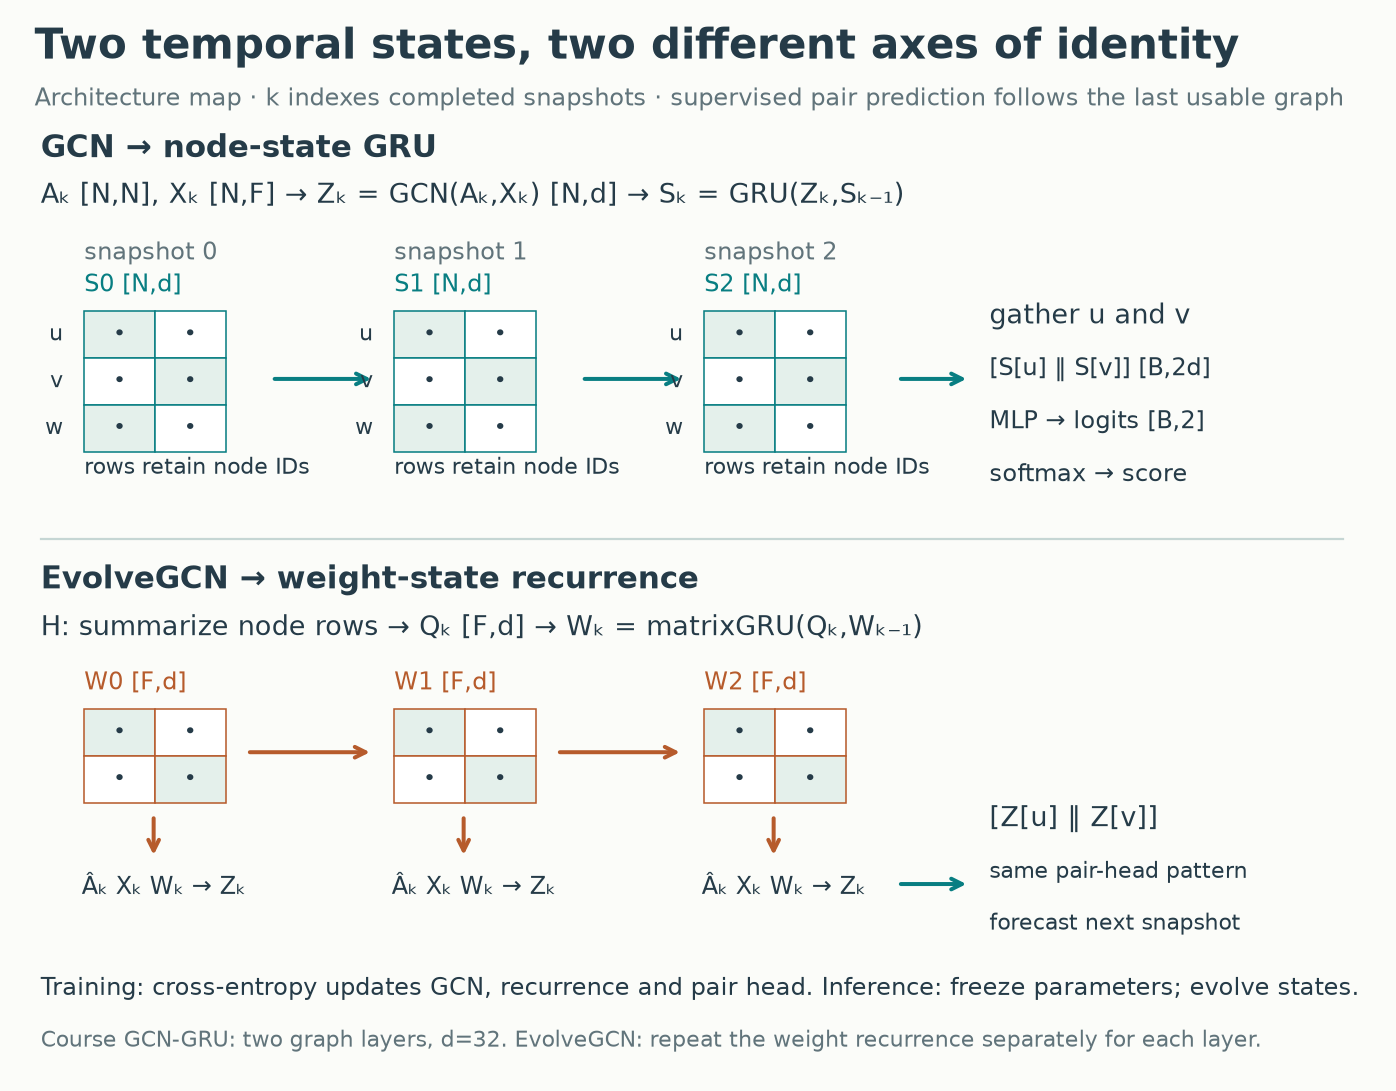<figcaption>Two complete prediction paths: GCN-GRU carries node-indexed state; EvolveGCN carries feature-to-feature weights. Each supplies node vectors to a pair head.</figcaption></figure>

There are two separate directions of computation: **across neighbors inside one graph**, and **across time between graphs**. A graph convolutional network (GCN) supplies the first. A recurrent neural network supplies the second.

Our course baseline first encodes each slice, then updates a **node-state matrix** S. Row u of S is node u's history summary. This row must keep the same identity across slices. Our controlled experiment preallocates the released node-ID universe and initializes all rows to zero at the beginning. It then updates every row, including isolated and not-yet-observed nodes, so absence can change a state through the recurrent rule. A node’s state need not still be zero when its first event arrives. A genuinely growing registry needs a separate policy for initializing newly added rows. Reordering IDs without also reordering S silently transfers memories between entities.

EvolveGCN instead updates the **GCN weight matrix** W. These are feature-to-feature coefficients, not rows indexed by node identity. H consumes a summary of the current node representations when updating W. The released O update consumes W itself. This avoids a persistent per-node recurrent table in the EvolveGCN encoder; it does not recover event order lost when snapshots were built. Read [the authors' method, §3](https://arxiv.org/html/1902.10191v3#S3) alongside the [pinned implementation](https://github.com/IBM/EvolveGCN/tree/3f4996ac2a742a69fe6ce6e378b6317518bd99bf).

| Object | Shape | Meaning |
|---|---|---|
| A | N × N | Weighted adjacency of one completed graph |
| X | N × F | Features available for its N nodes |
| Z | N × d | Encoded node features after graph convolutions |
| S | N × d | GCN-GRU's recurrent state, indexed by node |
| W | F × d | One EvolveGCN layer's recurrent weight matrix |
| Pair logits | B × 2 | Two class scores for B supplied node pairs |

N counts nodes, F input features, d hidden coordinates, and B candidate pairs. The pair head concatenates two node vectors and maps them through a small neural network to two logits. Softmax converts those logits to a probability for the supplied candidate distribution. Cross-entropy trains the encoder and head together. This does **not** identify the probability that an arbitrary real-world interaction will happen without a corresponding candidate and horizon contract.



## 3 · Work one spatial update before adding time

Add the identity matrix I to A so each node can retain its own features. Let D be the diagonal matrix of row sums of A+I. The normalized adjacency is `Â = D^(-1/2) (A+I) D^(-1/2)`. One layer computes `Z = σ(Â X W)`: mix feature coordinates with W, mix neighboring rows with Â, then apply a nonlinear function σ. The diagonal entries of D are degrees **after** self-loops were added. This is symmetric normalization; it is not generally a row-stochastic neighbor average.

<figure class="stream-figure" tabindex="0">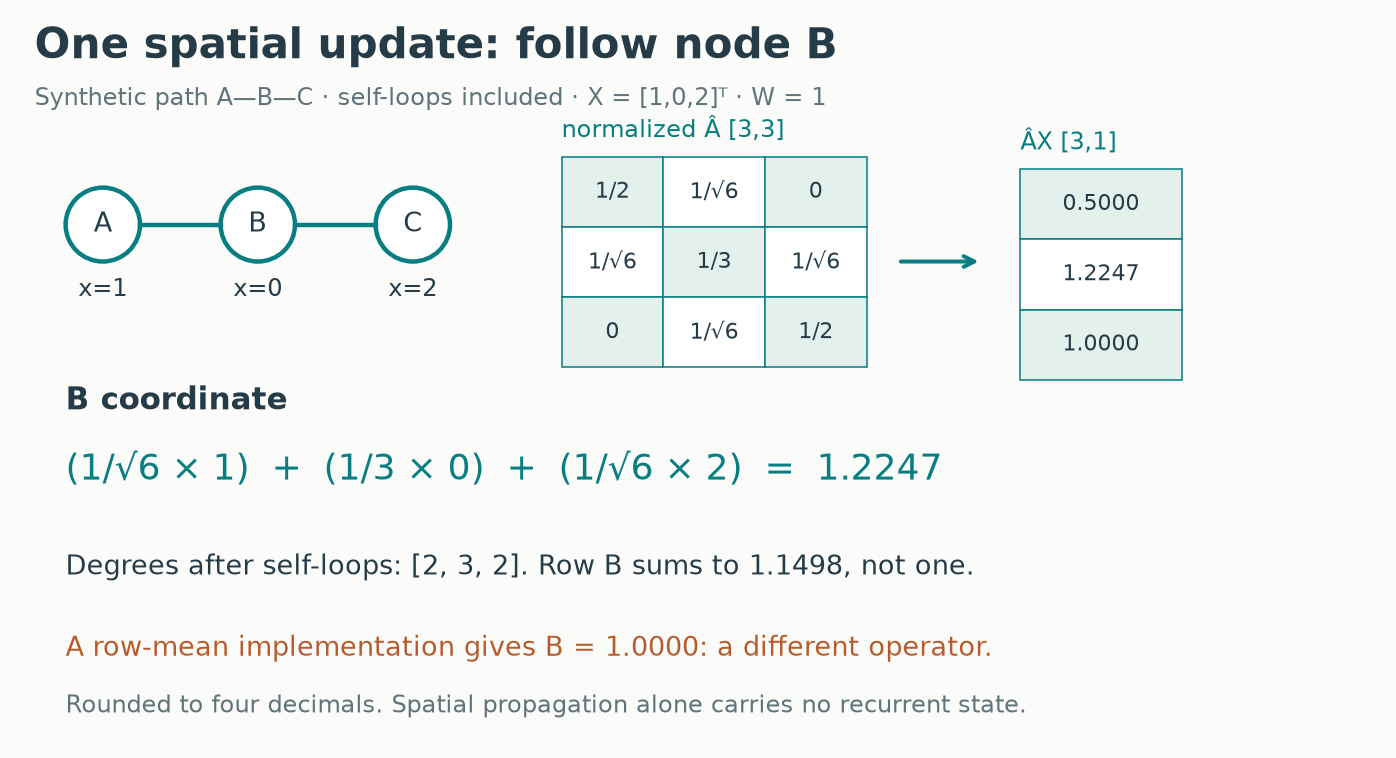<figcaption>Synthetic path A–B–C. Degree normalization with self-loops sends node B to 1.2247; row averaging would give 1.0000.</figcaption></figure>

For the path A—B—C, use one feature per node: X = [1, 0, 2]ᵀ and the scalar weight W = 1. After self-loops the degrees are [2, 3, 2]. B receives `1/√6 × 1 + 1/3 × 0 + 1/√6 × 2 = 1.2247`. A receives 0.5; C receives 1.0. ReLU, which replaces negative values with zero, leaves these positive outputs unchanged. No term in this calculation contains yesterday's state. This is why a temporal mechanism is an additional design choice. The normalization follows [EvolveGCN Eq. 1 and §3.1](https://arxiv.org/html/1902.10191v3#S3.SS1).

Implement the normalization in TODO 1 below; the later graph computations call your function.

**Check:** If you normalize each row to sum to one, what value does B obtain? It becomes 1.0, so this substitution changes the operator even though both implementations may be called “normalized adjacency.”



## 4 · Let a node remember between slices

A **gated recurrent unit (GRU)** combines new input with previous state. In the baseline, the input is node u's encoded vector Zₖ[u], and the previous state is Sₖ₋₁[u]. The same learned GRU is applied to every node row. Its gates can preserve earlier information or replace it with a proposed new state.

Our library GRU uses an update gate z with `S_new = (1−z) × candidate + z × S_old`: z near one retains the old state. The EvolveGCN paper's matrix update uses the *opposite naming convention*: z near one selects the new candidate. Symbols alone do not establish equivalent code. Both can express a gated interpolation.

A course forward pass is: completed graph → two GCN layers → rowwise GRU → concatenate candidate endpoint states → pair classifier. During training, the loss on later events differentiates through the preceding graph update. We detach the carried state at each window, so this baseline uses one-window truncated backpropagation: its values can remember farther back, but its gradients do not traverse the entire month. During evaluation, weights are frozen while states continue to update from newly available observations.

**Predict before moving the control:** if the new candidate is larger than the previous state, does increasing the retention gate increase or decrease the output?

**Portable node-gate trace:** initial 0.20; candidates [0.80, 0.10, 0.60]; retention gate 0.25 gives states [0.6500, 0.2375, 0.5094]. Predict first, then calculate.

The control is a scalar gate illustration with supplied candidates, not a fitted neural network. It isolates interpolation. In the real GRU, candidate and gate values are functions of the input and previous state.



## 5 · Let the graph convolution's weights remember

EvolveGCN-H has a different recurrent state. A layer needs a matrix W of shape F × d. Its N × F node representation cannot directly serve as an F × d matrix input. The release learns a scoring vector p, computes a score `xᵤ·p / ‖p‖` for each node, selects d active rows with the largest scores, weights those rows by tanh of their scores, and transposes the result. The resulting **summary Q** has exactly F × d entries. Top-k selects representatives; it does not average every node. If fewer than d active rows remain, the release repeats its last selected row. An all-inactive input is unsupported by that released operation.

<figure class="stream-figure" tabindex="0">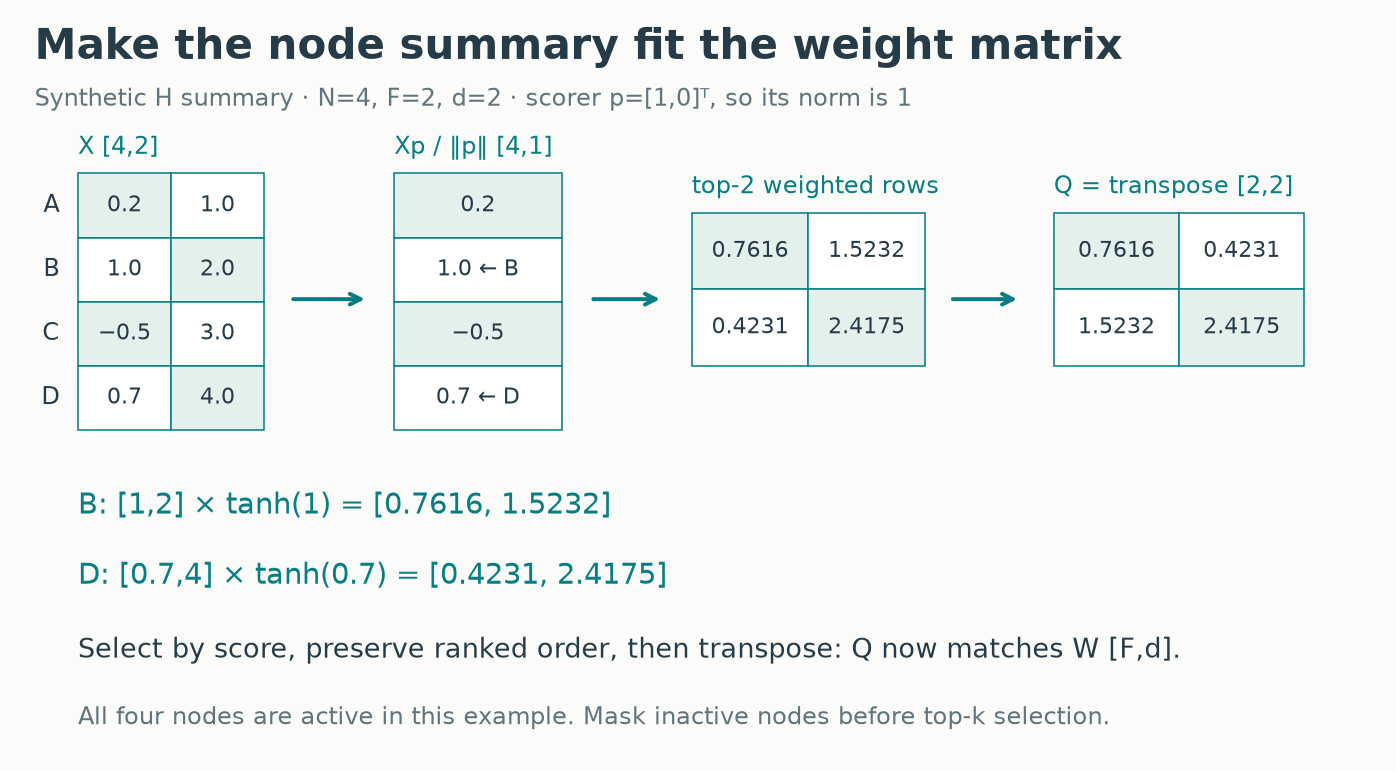<figcaption>Synthetic H top-k calculation: score four node rows, select B and D, weight by tanh, then transpose to a 2-by-2 summary matching W.</figcaption></figure>

In this separate summary example, p = [1,0] selects nodes B and D by their first coordinate. Multiplying their entire rows by tanh of the score and transposing gives the pictured Q. The next diagram isolates the interpolation step with supplied gate and candidate values.

<figure class="stream-figure" tabindex="0">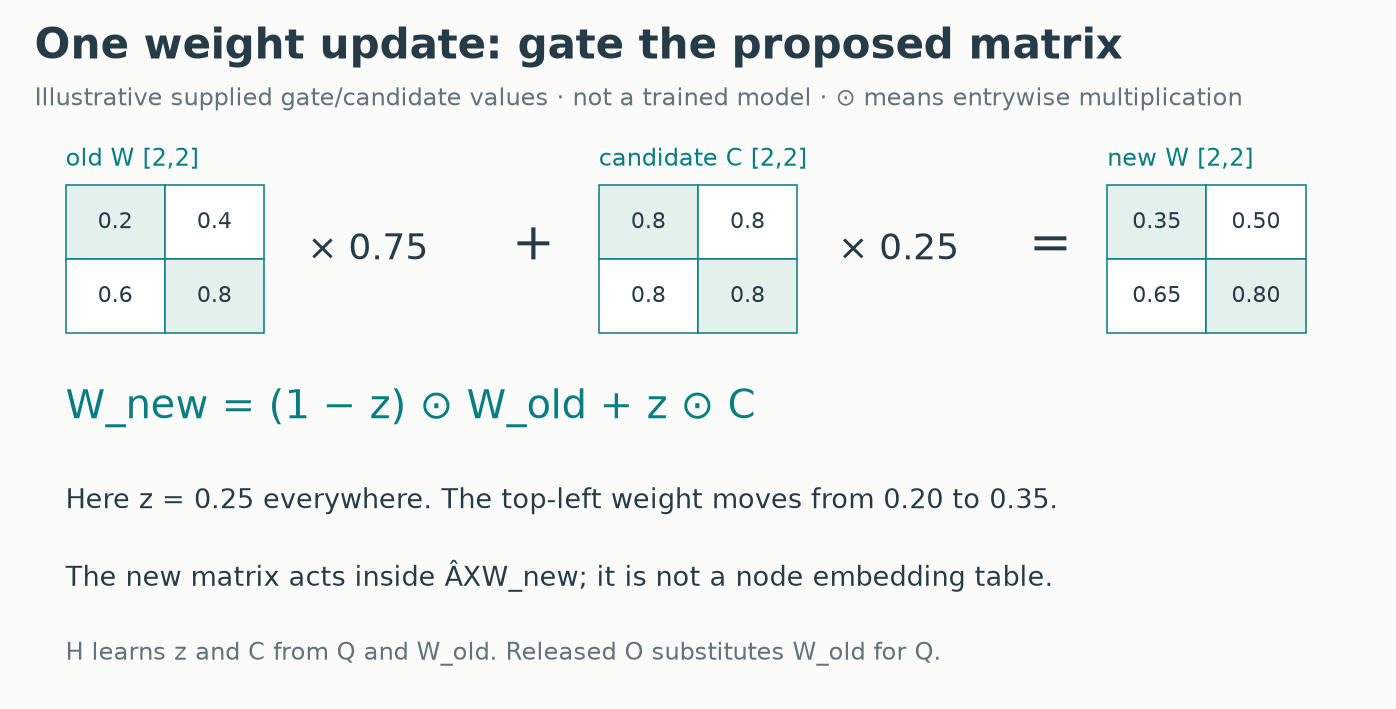<figcaption>Synthetic matrix interpolation with replacement gate 0.25. The top-left weight changes from 0.20 to 0.35 before it is used in graph convolution.</figcaption></figure>

The matrix gates are `z = sigmoid(U_z Q + V_z W_old + B_z)` and `r = sigmoid(U_r Q + V_r W_old + B_r)`. Each sigmoid produces values between zero and one. The candidate is `C = tanh(U_c Q + V_c(r ⊙ W_old) + B_c)`, where ⊙ denotes entrywise multiplication. Then `W_new = (1−z) ⊙ W_old + z ⊙ C`. U and V are learned F × F matrices; each B is an F × d bias. The new W is used immediately in the current graph convolution. These are the [matrix recurrence and summary in §3.4](https://arxiv.org/html/1902.10191v3#S3.SS4).

**Portable weight-gate trace:** same initial state and candidates; replacement gate 0.25 gives [0.3500, 0.2875, 0.3656]. Explain the changed convention.

**Implementation prediction:** Is setting z=1 a “remember everything” setting in this matrix recurrence? No: it discards W_old's direct interpolation contribution, although W_old can still influence the candidate through the reset path.

**A consequential release discrepancy.** Paper §3.5 specifies an LSTM for O, including a separate cell state. The released `egcn_o.py` uses the matrix-GRU-style gate code and feeds W_old as its own input. Our replay preserves the code and labels it **released O**. A matching released score cannot establish an LSTM reproduction.

**Predict before the witness:** under fixed mean-slope activations, can H, released O, or both respond to an early-snapshot intervention?

<figure class="stream-figure" tabindex="0">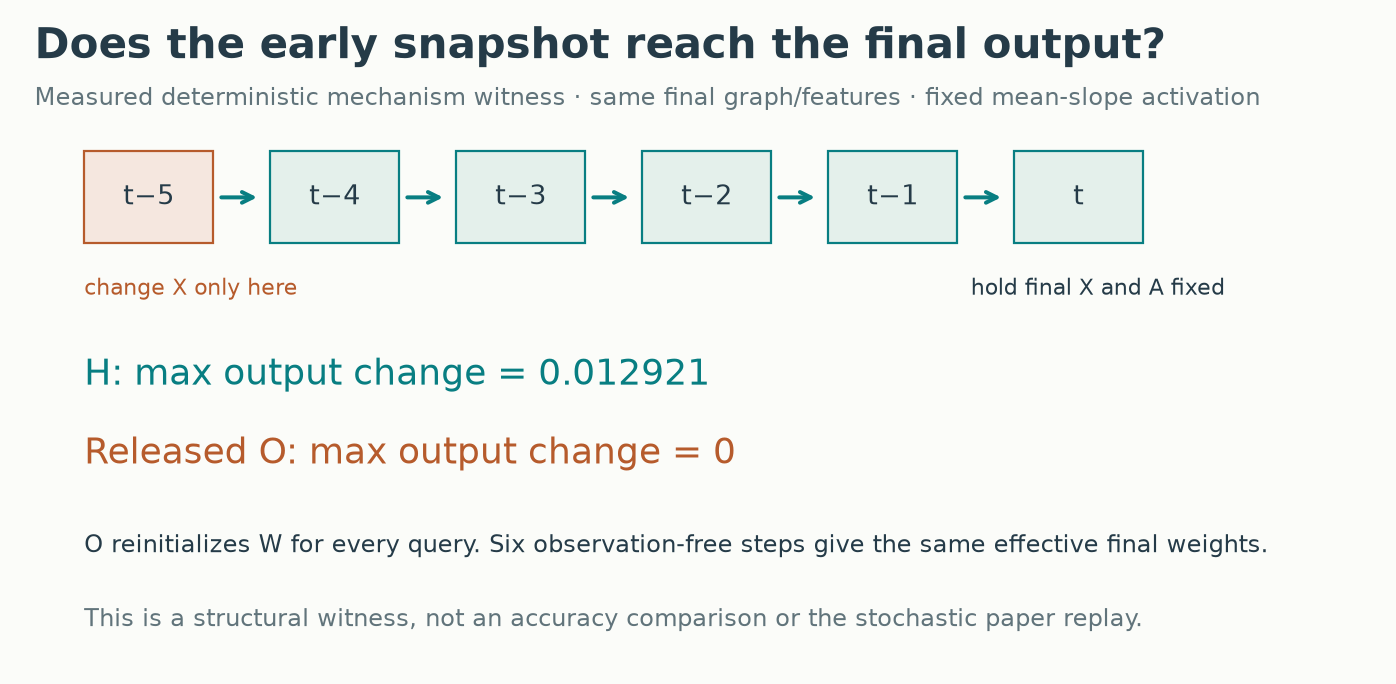<figcaption>Measured deterministic mechanism witness: changing the first snapshot changes H, but not released O. Fixed mean-slope activations isolate content dependence.</figcaption></figure>

There is a second, subtler boundary: the release restarts W from learned initial weights for every six-slice query. In released O, each weight update ignores observations. Six identical recurrent transformations therefore produce the same final effective weights for every window. Holding the final graph/features fixed and replacing an earlier graph's features leaves the deterministic final output unchanged. H can respond because its summary depends on those earlier features.

Our witness replaces stochastic RReLU activations by their fixed mean slope to isolate this dependence; it is **not** a paper-score run. With stochastic activations enabled, changing earlier signs may consume different random draws and perturb later outputs. That random-stream effect is not evidence that the model learned useful historical content. Trace the data dependency, then test it.



## 6 · Predict, then inspect the evidence

Before the table, write a ranking for hourly snapshots, daily snapshots and event-based TGN. Give a reason and one observation that would make you revise it.

**Wikipedia course comparison — held fixed:** the released train/validation/test populations, positive questions, negative destination arrays, raw edge features, three seeds, ten epochs, learning rate 0.001, hidden width 32, validation-AP checkpoint selection, and pooled metrics. All arms use strict-past information; graph windows are accessible only after closing. TGN keeps event timing and raw messages, whereas the snapshot model uses per-node mean incident features, counts and a completed-window graph. Thus accessible past information is intentionally represented with different delays and compression. The snapshot baseline does not receive individual event timestamps after aggregation.

**Varied:** architecture and its update schedule; snapshot width is one hour or one day. Epoch counts do not equalize optimizer-step counts or gradient horizons. Snapshot evaluation rebuilds its history under frozen weights; TGN carries the selected online training/validation memory, including pending messages. State construction is another system difference. There is one dataset and a fixed configuration, not a hyperparameter search proving which family is best. The compact TGN here is a fresh course fit, not one of L102's published-target scores. AP is precision averaged at positive-score thresholds; AUROC measures positive-versus-negative score ordering, giving half credit to ties. Both are pooled over the entire test set here, unlike some source batch averages in L106.

**SBM released replay — a different lane:** full 1,000-node, 50-snapshot dataset; H and released O, seed 1234, released configuration and up to 100 epochs with the released patience rule. The 0-based input-window end indices are 5–33 for training, 34–38 for validation and 39–48 for test; labels come from the following snapshot. `num_hist_steps=5` yields six inputs, t−5 through t. Validation and test evaluate all 1,000,000 ordered node pairs, including self-pair negatives. The paper's MAP is mean snapshot-level average precision, and its MRR averages reciprocals of **all positive ranks** within each source node, then across nodes and snapshots. It is not reciprocal rank of just the first correct neighbor.

**Author-run reference evidence**, not your current notebook output.

| Wikipedia arm | Pooled AP, mean ± sample SD | Pooled AUROC, mean ± sample SD | Complete fits |
|---|---:|---:|---:|
| Hourly GCN-GRU | 0.9112 ± 0.0034 | 0.9023 ± 0.0030 | 3 × 10 epochs |
| Daily GCN-GRU | 0.8411 ± 0.0128 | 0.8259 ± 0.0100 | 3 × 10 epochs |
| Compact TGN | 0.9680 ± 0.0021 | 0.9668 ± 0.0019 | 3 × 10 epochs |

Each fit covers all 81,029 training, 23,621 validation and 23,621 test positive events. Predictions are matched by raw event ID and class before comparing methods. SD measures variation across these seeds, not uncertainty over datasets or future deployments.

| SBM variant | Epochs / selected epoch (0-based) | MAP / paper | MRR / paper | Numeric verdict |
|---|---:|---:|---:|---|
| Released H | 67 / 15 | 0.1793 / 0.1947 | 0.0132 / 0.0141 | MAP FAIL; MRR CLOSE |
| Released O | 100 / 90 | 0.1900 / 0.1989 | 0.0143 / 0.0138 | MAP CLOSE; MRR CLOSE |

**H MAP misses the predeclared CLOSE threshold:** absolute gap 0.015423 exceeds 0.015. The full declared run completed, but this published number was not numerically reproduced within that tolerance. Source agreement does not erase the gap; no test-driven retuning was performed.

**Interpretation:** Wikipedia ranks these configured systems on one frozen candidate population. It does not isolate the effect of discretization: encoder, update frequency and gradient horizon also change. The SBM cells test a named released configuration, with source/prose and runtime deviations retained. Neither lane establishes full-paper or historical identity.


<figure class="stream-figure" tabindex="0">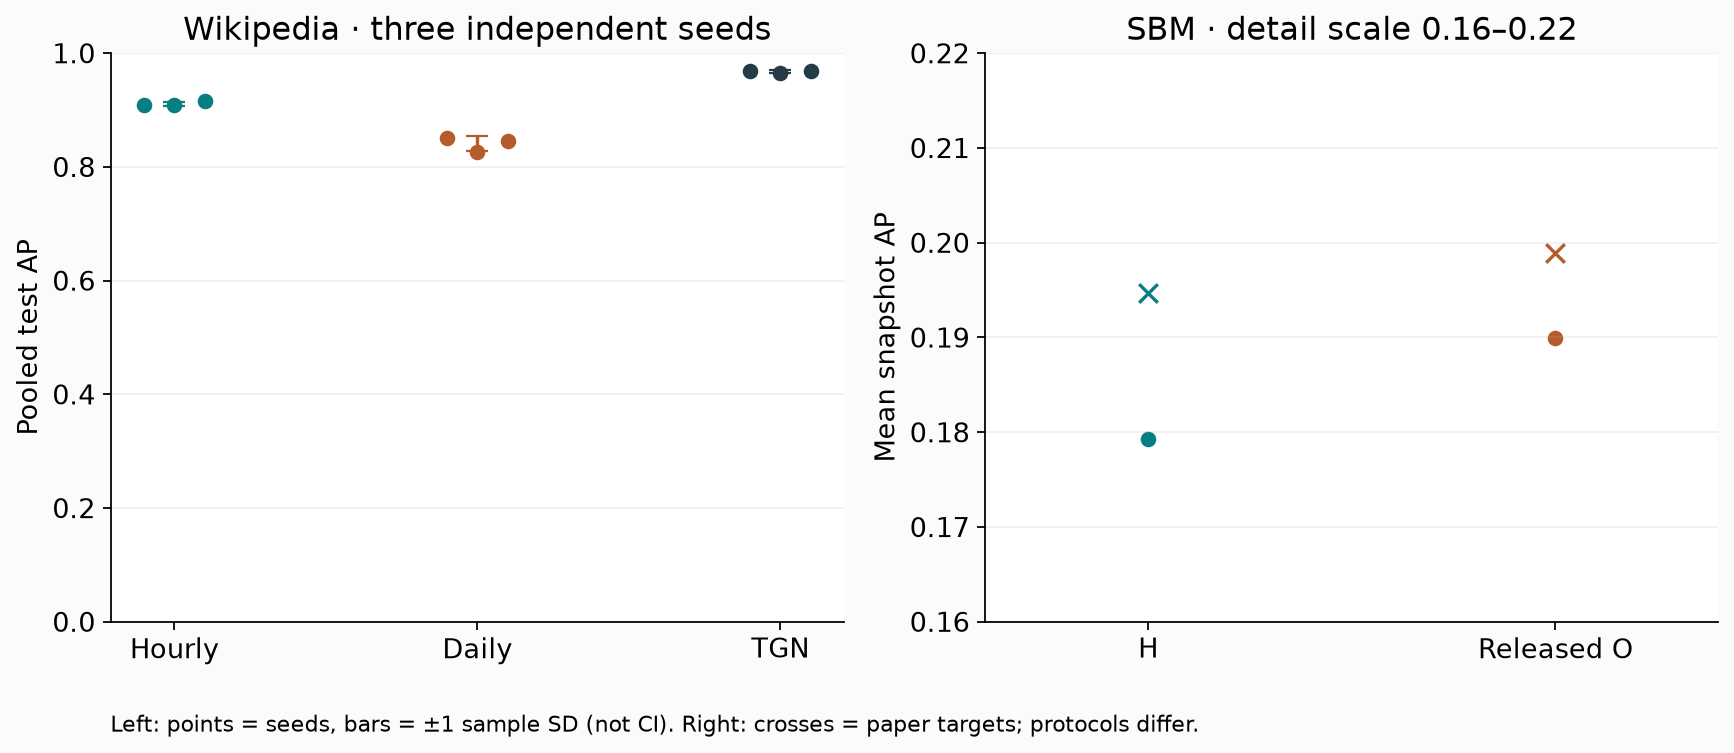<figcaption>Author evidence: all three Wikipedia seeds and sample SD; full selected SBM released runs versus paper targets. Different tasks and candidate universes are not directly comparable.</figcaption></figure>

### What would count as reproduction?

The source/data audit independently checks all 50 snapshot adjacencies, degree features and normalizations. The port is checked against the original model's values and gradients; pair-head chunking is checked against one unchunked loss/gradient calculation. Saved prediction files support independent metric reconstruction. The original metric methods and independent formulas also run in the pinned environment. Tied scores expose a small runtime dependency in NumPy’s default rank ordering; a separate audit bounds all rankings within each tied group. These checks establish specific properties, not historical identity.

Remaining deviations are substantive: current libraries and hardware; one explicit negative-sampler RNG stream instead of eight worker streams; chunked gradient reduction; degree-feature dimensionality scanned across future snapshots in the release; stochastic RReLU left active during validation; and the O GRU/LSTM discrepancy. The degree scan fixes a feature schema from later data, so the paper replay must not be advertised as a clean production information protocol. See the complete [reproduction contract](https://avistian.github.io/relational/labs/l107-reproduction.md) and [source manifest](https://avistian.github.io/relational/labs/_sources_l107.json). All other datasets, baselines and paper ablations are **NOT_RUN**.



## 7 · Lab: make the memory contract executable

Open the [student notebook](https://avistian.github.io/relational/labs/0107-snapshot-methods.ipynb), [prepared HTML](https://avistian.github.io/relational/labs/html/0107-snapshot-methods.html), or [executed solution](https://avistian.github.io/relational/labs/solutions/0107-snapshot-methods.ipynb). The notebook includes the readable models and training loops. Its short, full-data daily fit is teaching evidence; the longer named experiment is a separately gated replay.

1. **TODO 1:** construct a weighted, self-looped normalized adjacency. Preserve repeated-edge counts.
2. **TODO 2:** implement the matrix-state update with the paper's gate convention. A wrong interpolation direction must fail the gradient/value check.
3. **TODO 3:** return only bins whose closing boundary is available at a query. Equality at the closing time is legal; equality with an event inside the current unfinished bin is not enough.

After each task run its CHECK. The graph layer, recurrence and full-data availability audit call your functions; the notebook never silently replaces your answers. Then predict the history-intervention outcome and run the experiment.

### EXIT · defend a snapshot model

Explain a prediction at 09:05 for an hourly model: identify the last usable graph, the recurrent object's shape, the pair head, and which observations update the state afterward. Distinguish absent nodes from unseen nodes. Explain why source parity, a nearby MAP and a large state are each insufficient to prove historical reproduction or useful temporal memory. Finally, propose one matched intervention to separate information delay from model capacity.

**Write the EXIT defense and send it to the teacher for feedback.**

Send your code and written defense to the teacher for feedback; ask follow-up questions about any unclear step. The package is **PENDING_WRITTEN_DEFENSE**, not a record of learner mastery.

**Primary reading:** Pareja et al., [EvolveGCN, §3–4](https://arxiv.org/html/1902.10191v3), especially Figures 1–2 and Table 2, then compare `egcn_o.py` and `splitter.py` in the [publication-era source](https://github.com/IBM/EvolveGCN/tree/3f4996ac2a742a69fe6ce6e378b6317518bd99bf). For the event-based alternative, revisit [TGN §3](https://arxiv.org/html/2006.10637v3#S3) and [L102](https://avistian.github.io/relational/lessons/0102-temporal-graph-networks.html). Keep the [snapshot reference](https://avistian.github.io/relational/reference/snapshot-state-contracts.html) beside your implementation.

**Next:** L108 makes temporal neighbor sampling efficient. The question changes from “what history is legal?” to “how can we retrieve enough of that history within a batch budget?”


## Implement the three load-bearing operations

Work in order. Definitions below remain live throughout the model and data computations. The solution notebook fills the same functions; there is no hidden replacement cell.

### PROVIDED · Module provenance

Trace its inputs and the state it returns; the next section will call this code.

In [ ]:
"""Readable GCN-GRU and EvolveGCN release port (IBM, Apache-2.0, 3f4996a).
The release O cell is a matrix GRU, NOT the LSTM described in paper section 3.5.
"""

### PROVIDED · Imports

Trace its inputs and the state it returns; the next section will call this code.

In [ ]:
import math
import numpy as np
import torch
from torch import nn

### TODO 1: normalize a completed snapshot

Preserve edge multiplicity, add one loop per node, and normalize with the two endpoint degrees. Return a coalesced sparse tensor.

In [ ]:
def normalized_adjacency(pairs, weights, n):
    raise NotImplementedError("TODO: normalized_adjacency")

In [ ]:
p = np.array([[0, 1], [1, 0], [1, 2], [2, 1], [0, 1]])
a = normalized_adjacency(p, np.ones(5), 4).to_dense().numpy()
raw = np.eye(4)
for i, j in p:
    raw[i, j] += 1
d = raw.sum(1)
np.testing.assert_allclose(
    a,
    raw / np.sqrt(d[:, None] * d[None, :]),
    rtol=1e-6,
    err_msg="Keep repeats, add self loops, normalize both endpoints",
)
assert a[3, 3] == 1, "An isolated node retains its self loop"
print("CHECK 1 PASS: weighted edges and isolated nodes")

### TODO 2: evolve a matrix state

Compute update/reset gates, a reset-conditioned candidate and the paper-convention interpolation. Do not detach tensors.

In [ ]:
def matrix_update(previous, summary, gates):
    raise NotImplementedError("TODO: matrix_update")

In [ ]:
previous = torch.tensor([[0.2, 0.4], [0.6, 0.8]], requires_grad=True)
q = torch.zeros_like(previous)
gates = [
    lambda x, h: torch.full_like(h, 0.25),
    lambda x, h: torch.ones_like(h),
    lambda x, h: torch.full_like(h, 0.8),
]
y = matrix_update(previous, q, gates)
torch.testing.assert_close(y, torch.tensor([[0.35, 0.50], [0.65, 0.80]]))
y.sum().backward()
torch.testing.assert_close(previous.grad, torch.full_like(previous, 0.75))
q = torch.ones(2, 2) * 0.1
p = torch.ones(2, 2) * 0.4
gates = [
    lambda x, h: torch.full_like(h, 0.7),
    lambda x, h: torch.full_like(h, 0.5),
    lambda x, h: torch.tanh(x + h),
]
torch.testing.assert_close(
    matrix_update(p, q, gates), 0.3 * p + 0.7 * torch.tanh(q + 0.5 * p)
)
print("CHECK 2 PASS: values, reset conditioning and old-state gradient")

### PROVIDED · Released objective

Trace its inputs and the state it returns; the next section will call this code.

In [ ]:
def weighted_cross_entropy(logits, labels, weights):
    """IBM Cross_Entropy.py: divide by number of examples, not sum of weights."""
    return (
        weights[labels]
        * (
            -logits.gather(1, labels[:, None]).flatten()
            + torch.logsumexp(logits, dim=1)
        )
    ).mean()

### PROVIDED · Matrix gates and learned top-k summary

Trace its inputs and the state it returns; the next section will call this code.

In [ ]:
class MatrixGate(nn.Module):
    def __init__(self, rows, cols, activation):
        super().__init__()
        self.activation = activation
        self.W = nn.Parameter(torch.empty(rows, rows))
        nn.init.uniform_(self.W, -1 / math.sqrt(rows), 1 / math.sqrt(rows))
        self.U = nn.Parameter(torch.empty(rows, rows))
        nn.init.uniform_(self.U, -1 / math.sqrt(rows), 1 / math.sqrt(rows))
        self.bias = nn.Parameter(torch.zeros(rows, cols))

    def forward(self, x, h):
        return self.activation(self.W @ x + self.U @ h + self.bias)


class TopSummary(nn.Module):
    def __init__(self, rows, k):
        super().__init__()
        self.k = k
        self.scorer = nn.Parameter(torch.empty(rows, 1))
        nn.init.uniform_(self.scorer, -1 / math.sqrt(rows), 1 / math.sqrt(rows))

    def forward(self, x, mask):
        scores = x @ self.scorer / self.scorer.norm() + mask
        values, indices = scores.flatten().topk(self.k)
        indices = indices[values > -float("inf")]
        if not len(indices):
            raise ValueError("Release TopK is undefined with no active nodes")
        if len(indices) < self.k:
            indices = torch.cat([indices, indices[-1].repeat(self.k - len(indices))])
        return (x[indices] * torch.tanh(scores[indices])).T


class EvolvingLayer(nn.Module):
    def __init__(self, rows, cols, variant):
        super().__init__()
        self.variant = variant
        self.gates = nn.ModuleList(
            [
                MatrixGate(rows, cols, torch.sigmoid),
                MatrixGate(rows, cols, torch.sigmoid),
                MatrixGate(rows, cols, torch.tanh),
            ]
        )
        # Retain the O release's unused scorer so parameter initialization consumes the same RNG.
        self.summary = TopSummary(rows, cols)
        self.initial = nn.Parameter(torch.empty(rows, cols))
        nn.init.uniform_(self.initial, -1 / math.sqrt(cols), 1 / math.sqrt(cols))

    def forward(self, adj, features, masks):
        w = self.initial
        outputs = []
        for a, x, mask in zip(adj, features, masks):
            q = self.summary(x, mask) if self.variant == "H" else w
            w = matrix_update(w, q, self.gates)
            # Source RReLU stays in training mode during validation too.
            outputs.append(
                nn.functional.rrelu(
                    a @ (x @ w), lower=1 / 8, upper=1 / 3, training=True
                )
            )
        return outputs


class EvolveGCN(nn.Module):
    def __init__(self, features, hidden, variant):
        super().__init__()
        self.layers = nn.ModuleList(
            [
                EvolvingLayer(features, hidden, variant),
                EvolvingLayer(hidden, hidden, variant),
            ]
        )

    def forward(self, adj, features, masks):
        for layer in self.layers:
            features = layer(adj, features, masks)
        return features[-1]


class PairClassifier(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * dim, hidden), nn.ReLU(), nn.Linear(hidden, 2)
        )

    def forward(self, z, pairs):
        return self.mlp(torch.cat([z[pairs[:, 0]], z[pairs[:, 1]]], 1))

### TODO 3: legal snapshot cutoff

Keep the bin index for each eligible event, including duplicates. Eligibility depends on the scheduled bin end, not the event time alone.

In [ ]:
def completed_bins(times, width, query):
    raise NotImplementedError("TODO: completed_bins")

In [ ]:
times = np.array([0.0, 9.9, 10.0, 10.0, 20.1])
np.testing.assert_array_equal(completed_bins(times, 10, 10), [0, 0])
np.testing.assert_array_equal(completed_bins(times, 10, 20), [0, 0, 1, 1])
assert len(completed_bins(times, 10, 9.99)) == 0
assert len(completed_bins([], 10, 99)) == 0
print("CHECK 3 PASS: exact close, ties, empty input")

### PROVIDED · Course GCN followed by node-state GRU

Trace its inputs and the state it returns; the next section will call this code.

In [ ]:
class SnapshotGRU(nn.Module):
    def __init__(self, input_dim, hidden=32):
        super().__init__()
        self.input_dim = input_dim
        self.hidden = hidden
        self.gcn1 = nn.Linear(input_dim, hidden, bias=False)
        self.gcn2 = nn.Linear(hidden, hidden, bias=False)
        self.gru = nn.GRUCell(hidden, hidden)
        self.decoder = PairClassifier(hidden, hidden)

    def step(self, a, x, state):
        z = torch.relu(a @ self.gcn1(x))
        z = torch.relu(a @ self.gcn2(z))
        return self.gru(z, state)

    def score(self, state, pairs):
        return self.decoder(state, pairs)

## PROVIDED · TGN baseline and raw Wikipedia loader

This is the visible L102 model port. Its original paper-target trainer is retained for inspection, but the matched course experiment uses the separate trainer below: smaller memory, no dropout, fixed candidates and validation-best checkpointing. No archived L102 score is substituted for a new fit.

In [ ]:
"""Visible one-layer TGN-attn port for L102 (Rossi et al., 2020).

Apache-2.0 source reference: twitter-research/tgn e38cdf85998c6ca077167610dc4e769a688efa95.
This focused port supports the released Wikipedia TGN-attn setting, not all TGN variants.
"""

### PROVIDED · Imports and immutable experiment identities

In [ ]:
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import average_precision_score, roc_auc_score

SOURCE_COMMIT = "e38cdf85998c6ca077167610dc4e769a688efa95"
DATA_URL = "https://snap.stanford.edu/jodie/wikipedia.csv"
DATA_SHA256 = "a6b73e09c0d1e5b9db11e7e7aa416f2e87838a745273e0446a79952cf4cfae09"
PAPER_AP = {"all": 98.46, "new": 97.81}
CLOSE_TOLERANCE_PP = 0.5

### PROVIDED · Task 1: last-message aggregation

In [ ]:
def last_message_indices(node_ids):
    """Last occurrence per node, returned in sorted-node order (chronological input)."""
    last = {}
    for i, node in enumerate(node_ids):
        last[int(node)] = i
    return np.array([last[node] for node in sorted(last)], dtype=np.int64)

### PROVIDED · Task 2: raw interaction messages

In [ ]:
def raw_messages(own, other, edge, elapsed, time_encoder):
    """Eq. 1 identity message: [own state, other state, event features, elapsed encoding]."""
    return torch.cat(
        [own, other, edge, time_encoder(elapsed[:, None]).squeeze(1)], dim=1
    )

### PROVIDED · Task 3: differentiable memory update

In [ ]:
def update_state(memory, last_update, nodes, messages, timestamps, gru):
    """New candidate state; do not mutate the pre-event state that messages refer to."""
    state, clock = memory.detach().clone(), last_update.detach().clone()
    if len(nodes):
        assert bool(
            (clock[nodes] <= timestamps).all()
        ), "Memory would travel backward in time"
        state[nodes] = gru(messages, state[nodes])
        clock[nodes] = timestamps
    return state, clock

### PROVIDED · Strict temporal adjacency and release negative sampling

In [ ]:
def temporal_neighbors(u, v, t, edge_ids, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    for a, b, when, eid in zip(u, v, t, edge_ids):
        adjacency[int(a)].append((int(b), int(eid), float(when)))
        adjacency[int(b)].append((int(a), int(eid), float(when)))
    adjacency = [
        np.asarray(sorted(rows, key=lambda x: x[2]), dtype=np.float64).reshape(-1, 3)
        for rows in adjacency
    ]

    def find(nodes, cutoffs, count):
        neighbors = np.zeros((len(nodes), count), dtype=np.int64)
        ids = np.zeros_like(neighbors)
        times = np.zeros(neighbors.shape, dtype=np.float32)
        for row, (node, cutoff) in enumerate(zip(nodes, cutoffs)):
            history = adjacency[int(node)]
            end = np.searchsorted(history[:, 2], cutoff, side="left")
            chosen = history[max(0, end - count) : end]
            if len(chosen):
                neighbors[row, -len(chosen) :] = chosen[:, 0]
                ids[row, -len(chosen) :] = chosen[:, 1]
                times[row, -len(chosen) :] = chosen[:, 2]
        return neighbors, ids, times

    return find


class NegativeSampler:
    """Uniform destinations; consume the unused source draw to preserve release RNG order."""

    def __init__(self, events, seed=None):
        self.sources = np.unique(events["u"])
        self.destinations = np.unique(events["v"])
        self.seed = seed
        self.reset()

    def reset(self):
        self.rng = np.random if self.seed is None else np.random.RandomState(self.seed)

    def sample(self, size):
        self.rng.randint(0, len(self.sources), size)
        return self.destinations[self.rng.randint(0, len(self.destinations), size)]

### PROVIDED · Time encoder and merge blocks

In [ ]:
class TimeEncoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(1, dim)
        self.w.weight = nn.Parameter(
            torch.tensor(1 / 10 ** np.linspace(0, 9, dim), dtype=torch.float32)[:, None]
        )
        self.w.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, elapsed):
        return torch.cos(self.w(elapsed.unsqueeze(-1)))


class Merge(nn.Module):
    def __init__(self, left, right, hidden, out):
        super().__init__()
        self.fc1, self.fc2 = nn.Linear(left + right, hidden), nn.Linear(hidden, out)
        nn.init.xavier_normal_(self.fc1.weight)
        nn.init.xavier_normal_(self.fc2.weight)

    def forward(self, left, right):
        return self.fc2(torch.relu(self.fc1(torch.cat([left, right], dim=-1))))

### PROVIDED · Complete one-layer TGN-attn encoder and decoder

In [ ]:
class TGN(nn.Module):
    def __init__(self, node_features, edge_features, dropout=0.1, neighbors=10):
        super().__init__()
        d = node_features.shape[1]
        self.dim, self.neighbors = d, neighbors
        self.register_buffer(
            "node_features", torch.as_tensor(node_features, dtype=torch.float32)
        )
        self.register_buffer(
            "edge_features", torch.as_tensor(edge_features, dtype=torch.float32)
        )
        self.time_encoder = TimeEncoder(d)
        self.gru = nn.GRUCell(3 * d + edge_features.shape[1], d)
        self.merge = Merge(2 * d, d, d, d)
        self.attention = nn.MultiheadAttention(
            2 * d,
            2,
            kdim=2 * d + edge_features.shape[1],
            vdim=2 * d + edge_features.shape[1],
            dropout=dropout,
        )
        self.decoder = Merge(d, d, d, 1)
        self.register_buffer("memory", torch.zeros_like(self.node_features))
        self.register_buffer("last_update", torch.zeros(len(node_features)))
        self.pending = {}
        self.finder = None

    def reset_state(self):
        self.memory.zero_()
        self.last_update.zero_()
        self.pending = {}

    def detach_state(self):
        self.memory = self.memory.detach()
        self.pending = {
            k: (m.detach(), t.detach()) for k, (m, t) in self.pending.items()
        }

    def snapshot(self):
        return (
            self.memory.detach().clone(),
            self.last_update.clone(),
            {k: (m.detach().clone(), t.clone()) for k, (m, t) in self.pending.items()},
        )

    def restore(self, state):
        self.memory, self.last_update, self.pending = copy.deepcopy(state)

    def candidate_state(self):
        nodes = sorted(self.pending)
        messages = torch.stack([self.pending[k][0] for k in nodes]) if nodes else None
        times = torch.stack([self.pending[k][1] for k in nodes]) if nodes else None
        return update_state(
            self.memory, self.last_update, nodes, messages, times, self.gru
        )

    def embed(self, nodes, timestamps, state):
        device = self.memory.device
        node_ids = torch.as_tensor(nodes, dtype=torch.long, device=device)
        own = state[node_ids] + self.node_features[node_ids]
        neighbors, edges, times = self.finder(nodes, timestamps, self.neighbors)
        neighbors = torch.as_tensor(neighbors, dtype=torch.long, device=device)
        edges = torch.as_tensor(edges, dtype=torch.long, device=device)
        elapsed = torch.as_tensor(
            timestamps[:, None] - times, dtype=torch.float32, device=device
        )
        query = torch.cat(
            [
                own[:, None],
                self.time_encoder(torch.zeros((len(nodes), 1), device=device)),
            ],
            dim=-1,
        )
        key = torch.cat(
            [
                state[neighbors] + self.node_features[neighbors],
                self.edge_features[edges],
                self.time_encoder(elapsed),
            ],
            dim=-1,
        )
        mask = neighbors == 0
        empty = mask.all(dim=1)
        mask[empty, 0] = False  # MHA softmax must not receive an all-masked row.
        output, _ = self.attention(
            query.transpose(0, 1),
            key.transpose(0, 1),
            key.transpose(0, 1),
            key_padding_mask=mask,
        )
        output = output.squeeze(0).masked_fill(empty[:, None], 0)
        return self.merge(output, own)

    def probabilities(self, u, v, negative, timestamps, edge_ids):
        """Score first using old messages; queue current positive events only afterward."""
        state, clock = self.candidate_state()
        embeddings = self.embed(
            np.concatenate([u, v, negative]), np.tile(timestamps, 3), state
        )
        src, dst, neg = embeddings.chunk(3)
        # Persist consumed messages only for real endpoints, exactly as release TGN does.
        positives = np.unique(np.concatenate([u, v]))
        with torch.no_grad():
            self.memory[positives] = state[positives]
            self.last_update[positives] = clock[positives]
        for node in positives:
            self.pending.pop(int(node), None)
        device = self.memory.device
        when = torch.as_tensor(timestamps, dtype=torch.float32, device=device)
        # Source and destination messages both use the same pre-current-event state.
        for own, other in [(u, v), (v, u)]:
            messages = raw_messages(
                self.memory[own],
                self.memory[other],
                self.edge_features[edge_ids],
                when - self.last_update[own],
                self.time_encoder,
            )
            for idx in last_message_indices(own):
                self.pending[int(own[idx])] = (messages[idx], when[idx])
        scores = (
            self.decoder(torch.cat([src, src]), torch.cat([dst, neg]))
            .flatten()
            .sigmoid()
        )
        return scores.chunk(2)

### PROVIDED · Complete data preprocessing and frozen release split

In [ ]:
def load_wikipedia(directory):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    path = directory / "wikipedia.csv"
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL, path)
    sha = hashlib.file_digest(path.open("rb"), "sha256").hexdigest()
    assert sha == DATA_SHA256, f"Dataset checksum mismatch: {sha}"
    cache = directory / "processed.npz"
    if cache.exists():
        z = np.load(cache)
        # The raw identity alone cannot authenticate an arbitrary processed cache.
        if str(z["raw_sha"]) != sha:
            raise ValueError("Processed cache belongs to other raw bytes")
        u, v, t, x = (z[k] for k in ["u", "v", "t", "x"])
    else:
        # Header has four columns, rows additionally have 172 edge features.
        a = np.loadtxt(path, delimiter=",", skiprows=1)
        u = a[:, 0].astype(np.int64) + 1
        v = a[:, 1].astype(np.int64) + int(u.max()) + 1
        t, x = a[:, 2], a[:, 4:].astype(np.float32)
        np.savez(cache, u=u, v=v, t=t, x=x, raw_sha=sha)
    assert len(u) == 157474 and x.shape == (157474, 172)
    assert np.all(np.diff(t) >= 0) and len(set(u) | set(v)) == 9227
    edges = np.vstack([np.zeros((1, 172), np.float32), x])
    nodes = np.zeros((int(max(u.max(), v.max())) + 1, 172), np.float32)
    full = {"u": u, "v": v, "t": t, "e": np.arange(1, len(u) + 1)}
    val_time, test_time = np.quantile(t, [0.70, 0.85])
    candidates = set(u[t > val_time]) | set(v[t > val_time])
    # Python 3.9 random.sample(set, k) internally converted to tuple. Preserve that order.
    held = set(
        random.Random(2020).sample(tuple(candidates), int(0.1 * (len(nodes) - 1)))
    )
    train_mask = (t <= val_time) & ~np.isin(u, list(held)) & ~np.isin(v, list(held))
    seen = set(u[train_mask]) | set(v[train_mask])
    unseen = (set(u) | set(v)) - seen
    novel = np.isin(u, list(unseen)) | np.isin(v, list(unseen))
    masks = {
        "train": train_mask,
        "val": (t > val_time) & (t <= test_time),
        "test": t > test_time,
    }
    masks["new_val"] = masks["val"] & novel
    masks["new_test"] = masks["test"] & novel
    data = {name: {k: a[mask] for k, a in full.items()} for name, mask in masks.items()}
    data["full"] = full
    audit = {
        "raw_sha256": sha,
        "cutoffs": [float(val_time), float(test_time)],
        "counts": {k: len(d["u"]) for k, d in data.items()},
        "held_nodes": sorted(int(i) for i in held),
        "split_sha256": {
            k: hashlib.sha256(d["e"].tobytes()).hexdigest() for k, d in data.items()
        },
    }
    return nodes, edges, data, audit

### PROVIDED · Full chronological train/evaluation loops and named-target runner

In [ ]:
def batches(events, size=200):
    for start in range(0, len(events["u"]), size):
        yield {k: v[start : start + size] for k, v in events.items()}


def evaluate(model, events, sampler, batch_size=200):
    model.eval()
    sampler.reset()
    aps = []
    aucs = []
    saved = []
    with torch.no_grad():
        for b in batches(events, batch_size):
            neg = sampler.sample(len(b["u"]))
            positive, negative = model.probabilities(
                b["u"], b["v"], neg, b["t"], b["e"]
            )
            p = np.concatenate([positive.cpu().numpy(), negative.cpu().numpy()])
            y = np.concatenate([np.ones(len(positive)), np.zeros(len(negative))])
            aps.append(float(average_precision_score(y, p)))
            aucs.append(float(roc_auc_score(y, p)))
            saved.append(
                {
                    "edges": b["e"],
                    "negative": neg,
                    "positive": positive.cpu().numpy(),
                    "negative_score": negative.cpu().numpy(),
                }
            )
    return {
        "ap": float(np.mean(aps)),
        "auc": float(np.mean(aucs)),
        "batch_ap": aps,
        "batch_auc": aucs,
    }, saved


def run_training(
    nodes,
    edges,
    data,
    seed=0,
    epochs=50,
    patience=5,
    batch_size=200,
    output=None,
    device="cpu",
):
    """Fixed-seed modern port. Release checkpoint/pending-message behavior is preserved."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = TGN(nodes, edges).to(device)
    full_finder = temporal_neighbors(
        **{
            "u": data["full"]["u"],
            "v": data["full"]["v"],
            "t": data["full"]["t"],
            "edge_ids": data["full"]["e"],
            "n_nodes": len(nodes),
        }
    )
    train = data["train"]
    train_finder = temporal_neighbors(
        train["u"], train["v"], train["t"], train["e"], len(nodes)
    )
    train_sampler = NegativeSampler(train)
    val_sampler = NegativeSampler(data["full"], 0)
    test_sampler = NegativeSampler(data["full"], 2)
    new_sampler = NegativeSampler(data["new_test"], 3)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    trace = []
    best = -float("inf")
    rounds = 0
    best_epoch = 0
    best_weights = None
    stop = False
    for epoch in range(epochs):
        start = time.perf_counter()
        model.reset_state()
        model.finder = train_finder
        model.train()
        losses = []
        for b in batches(train, batch_size):
            optimizer.zero_grad()
            p, n = model.probabilities(
                b["u"], b["v"], train_sampler.sample(len(b["u"])), b["t"], b["e"]
            )
            loss = nn.functional.binary_cross_entropy(
                p, torch.ones_like(p)
            ) + nn.functional.binary_cross_entropy(n, torch.zeros_like(n))
            loss.backward()
            optimizer.step()
            model.detach_state()
            losses.append(float(loss.detach()))
        model.finder = full_finder
        train_state = model.snapshot()
        val, _ = evaluate(model, data["val"], val_sampler, batch_size)
        val_state = model.snapshot()
        model.restore(train_state)
        # The released trainer intentionally passes the full-node validation sampler here.
        new_val, _ = evaluate(model, data["new_val"], val_sampler, batch_size)
        model.restore(val_state)
        improved = best_weights is None or (val["ap"] - best) / abs(best) > 1e-10
        if improved:
            best = val["ap"]
            best_epoch = epoch
            rounds = 0
            best_weights = {
                k: v.detach().clone()
                for k, v in model.state_dict().items()
                if k not in ["node_features", "edge_features"]
            }
        else:
            rounds += 1
        row = {
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "val_ap": val["ap"],
            "new_val_ap": new_val["ap"],
            "seconds": time.perf_counter() - start,
        }
        trace.append(row)
        print(json.dumps({"seed": seed, **row}), flush=True)
        if output:
            Path(output).mkdir(parents=True, exist_ok=True)
            (Path(output) / f"seed-{seed}-progress.json").write_text(
                json.dumps(trace, indent=2)
            )
        if rounds >= patience:
            # Release does not serialize pending messages in state_dict. Keep stopping-epoch
            # pending messages when restoring its best weights and persistent memory.
            model.load_state_dict(best_weights, strict=False)
            stop = True
            break
    # Release uses the final epoch if the maximum is reached without early stopping.
    selected = best_epoch if stop else len(trace) - 1
    val_state = model.snapshot()
    test, predictions = evaluate(model, data["test"], test_sampler, batch_size)
    model.restore(val_state)
    new_test, new_predictions = evaluate(
        model, data["new_test"], new_sampler, batch_size
    )
    model.restore(val_state)
    result = {
        "seed": seed,
        "epochs_completed": len(trace),
        "selected_epoch": selected,
        "early_stopped": stop,
        "test": test,
        "new_test": new_test,
        "trace": trace,
        "seed_protocol": "Independent explicit seed per run; release originally seeds once before ten runs",
        "checkpoint_policy": "release: best state_dict on early stop; pending messages from stopping epoch",
    }
    if output:
        out = Path(output)
        torch.save(
            {
                "weights": {
                    k: v
                    for k, v in model.state_dict().items()
                    if k not in ["node_features", "edge_features"]
                },
                "temporal_state": model.snapshot(),
                "result": result,
            },
            out / f"seed-{seed}.pt",
        )
        arrays = {
            f"{lane}_{k}": np.concatenate([b[k] for b in values])
            for lane, values in [("all", predictions), ("new", new_predictions)]
            for k in values[0]
        }
        np.savez_compressed(out / f"seed-{seed}-predictions.npz", **arrays)
        (out / f"seed-{seed}.json").write_text(json.dumps(result, indent=2))
    return result

## PROVIDED · SBM: every step of the released replay

Inspect the splitter, available history, candidate sampler, loss reduction, validation selection and saved outputs. These are part of the experiment, not neutral boilerplate.

In [ ]:
"""Complete released SBM protocol, with bounded-memory pair-head backpropagation.
See l107-reproduction.md for deviations from historical runtime and worker RNG.
"""

### PROVIDED · SBM imports and authenticated data

In [ ]:
import hashlib, json, time, copy, urllib.request, tarfile
from pathlib import Path
import numpy as np, pandas as pd, torch
from sklearn.metrics import average_precision_score

SBM_SHA = "bfae7d9d89400b42c2ef513eaeef56dbbcfae2745c59f40fb3746f9cf98c8c45"
COMMIT = "3f4996ac2a742a69fe6ce6e378b6317518bd99bf"


def load_sbm(directory):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    raw = directory / "sbm.csv"
    if not raw.exists():
        archive = directory / "sbm.tar.gz"
        urllib.request.urlretrieve(
            f"https://raw.githubusercontent.com/IBM/EvolveGCN/{COMMIT}/data/sbm_50t_1000n_adj.csv.tar.gz",
            archive,
        )
        with tarfile.open(archive) as tar:
            m = next(x for x in tar.getmembers() if x.name.endswith(".csv"))
            raw.write_bytes(tar.extractfile(m).read())
    assert hashlib.file_digest(raw.open("rb"), "sha256").hexdigest() == SBM_SHA
    edges = pd.read_csv(raw).to_numpy(dtype=np.int64)
    edges[:, 3] -= edges[:, 3].min()
    n = int(edges[:, :2].max() + 1)
    last = int(edges[:, 3].max())
    pairs = []
    weights = []
    degrees = []
    for t in range(last + 1):
        e = edges[edges[:, 3] == t]
        p, w = np.unique(e[:, :2], axis=0, return_counts=True)
        pairs.append(p)
        weights.append(w)
        degrees.append(np.bincount(p[:, 0], minlength=n))
    f = int(np.max(degrees[:-1])) + 1  # source excludes final snapshot from schema scan
    features = [
        torch.nn.functional.one_hot(torch.as_tensor(d), f).float() for d in degrees
    ]
    adj = [normalized_adjacency(p, w, n) for p, w in zip(pairs, weights)]
    masks = []
    for p in pairs:
        mask = torch.full((n, 1), -float("inf"))
        mask[np.unique(p)] = 0
        masks.append(mask)
    return {
        "n": n,
        "f": f,
        "last": last,
        "pairs": pairs,
        "adj": adj,
        "features": features,
        "masks": masks,
        "rows": len(edges),
        "degrees": degrees,
    }

### PROVIDED · Released smart negative sampler, preserving first-occurrence order

In [ ]:
def smart_negatives(positive, existing, n, rng, mult=50):
    number = min(
        len(positive) * mult, len(positive) * (len(positive) - 1) - len(positive)
    )
    # Source draws all source IDs first, then all destinations. Preserve that RNG contract.
    source = rng.choice(positive[:, 0], size=number * 4, replace=True)
    target = rng.choice(existing, size=number * 4, replace=True)
    ids = source * n + target
    first = np.full(n * n, len(ids), dtype=np.int64)
    np.minimum.at(first, ids, np.arange(len(ids)))
    first[positive[:, 0] * n + positive[:, 1]] = len(ids)
    first[np.arange(n) * (n + 1)] = len(ids)
    accepted = np.flatnonzero(first < len(ids))
    order = np.argsort(first[accepted])
    accepted = accepted[order[:number]]
    return np.stack([accepted // n, accepted % n], axis=1)


def sbm_candidates(data, t, rng=None):
    positive = data["pairs"][t + 1]
    n = data["n"]
    if rng is None:
        # Original meshgrid flatten order: destination outer, source inner.
        ids = np.arange(n * n)
        pair = np.stack([ids % n, ids // n], 1)
        truth = np.zeros(n * n, bool)
        truth[positive[:, 0] * n + positive[:, 1]] = True
        neg = pair[~truth[pair[:, 0] * n + pair[:, 1]]]
    else:
        existing = np.concatenate(
            [np.unique(data["pairs"][i]) for i in range(t - 5, t + 1)]
        )
        neg = smart_negatives(positive, existing, n, rng)
    return np.concatenate([positive, neg]), np.concatenate(
        [np.ones(len(positive)), np.zeros(len(neg))]
    ).astype(np.int64)

### PROVIDED · Released MAP and average-over-positive-ranks MRR

In [ ]:
def sbm_metrics(pairs, labels, probs, n):
    ap = float(average_precision_score(labels, probs))
    score = np.zeros((n, n), dtype=probs.dtype)
    truth = np.zeros((n, n), dtype=bool)
    score[pairs[:, 0], pairs[:, 1]] = probs
    truth[pairs[:, 0], pairs[:, 1]] = labels.astype(bool)
    # Match source np.flip(row.argsort()), including its deterministic tie order.
    order = np.flip(score.argsort(axis=1), axis=1)
    ranked = np.take_along_axis(truth, order, axis=1)
    counts = truth.sum(1)
    rr = (ranked / np.arange(1, n + 1)).sum(1)
    mrr = float(np.mean(rr[counts > 0] / counts[counts > 0]))
    return {"map": ap, "mrr": mrr}

### PROVIDED · One complete graph-window training step, exact loss normalization

In [ ]:
def pair_pass(
    model, head, data, t, pairs, labels, device, training, weights, chunk=16384
):
    a = [x.to(device) for x in data["adj"][t - 5 : t + 1]]
    x = [v.to(device) for v in data["features"][t - 5 : t + 1]]
    mask = [v.to(device) for v in data["masks"][t - 5 : t + 1]]
    with torch.set_grad_enabled(training):
        z = model(a, x, mask)
        # Head chunks accumulate dL/dz before a single GCN backward; no truncated history.
        leaf = z.detach().requires_grad_(training)
        out = []
        loss_total = 0.0
        for start in range(0, len(pairs), chunk):
            p = torch.as_tensor(pairs[start : start + chunk], device=device)
            y = torch.as_tensor(labels[start : start + chunk], device=device)
            logits = head(leaf, p)
            loss = weighted_cross_entropy(logits, y, weights) * len(y) / len(labels)
            if training:
                loss.backward()
            loss_total += float(loss.detach())
            out.append(logits.softmax(1)[:, 1].detach().cpu().numpy())
        if training:
            z.backward(leaf.grad)
    return np.concatenate(out), loss_total

### PROVIDED · Complete released training budget and validation-only checkpoint selection

In [ ]:
def train_sbm(
    data, variant, output, device="cpu", epochs=100, max_seconds=10000, pilot=False
):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    start = time.perf_counter()
    torch.manual_seed(1234)
    np.random.seed(1234)
    # Source loader allocates random node features even though degree features replace them.
    torch.rand(data["n"], 3)
    h = 50 if variant == "H" else 51
    cls = 100 if variant == "H" else 565
    lr = 0.01 if variant == "H" else 0.005
    model = EvolveGCN(data["f"], h, variant).to(device)
    head = PairClassifier(h, cls).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    headopt = torch.optim.Adam(head.parameters(), lr=lr)
    weights = torch.tensor(
        [0.1, 0.9] if variant == "H" else [0.15, 0.85], device=device
    )
    train = list(range(5, int(np.floor(data["last"] * 0.7))))
    valid = list(range(train[-1] + 1, int(np.floor(data["last"] * 0.8))))
    test = list(range(valid[-1] + 1, data["last"]))
    rng = np.random.RandomState(1234)
    trace = []
    best = -float("inf")
    best_state = None
    best_epoch = None
    stale = 0
    status = "COMPLETE"
    eval_sets = {t: sbm_candidates(data, t) for t in valid + test}

    def evaluate(times, save=False):
        rows = []
        for t in times:
            pairs, y = eval_sets[t]
            if save:
                torch.save(
                    {
                        "cpu": torch.get_rng_state(),
                        "cuda": (
                            torch.cuda.get_rng_state_all()
                            if device.startswith("cuda")
                            else []
                        ),
                    },
                    output / f"test-{t}-rng.pt",
                )
            prob, _ = pair_pass(model, head, data, t, pairs, y, device, False, weights)
            metric = sbm_metrics(pairs, y, prob, data["n"])
            rows.append({"t": t, "count": len(y), **metric})
            if save:
                np.savez_compressed(
                    output / f"test-{t}.npz",
                    pairs=pairs.astype(np.int32),
                    y=y.astype(np.uint8),
                    prob=prob,
                )
        return {
            key: float(
                np.average([r[key] for r in rows], weights=[r["count"] for r in rows])
            )
            for key in ["map", "mrr"]
        }, rows

    for epoch in range(epochs):
        tick = time.perf_counter()
        losses = []
        counts = []
        for t in train[:1] if pilot else train:
            if time.perf_counter() - start > max_seconds:
                status = "INCOMPLETE"
                break
            pairs, y = sbm_candidates(data, t, rng)
            opt.zero_grad()
            headopt.zero_grad()
            _, loss = pair_pass(model, head, data, t, pairs, y, device, True, weights)
            opt.step()
            headopt.step()
            losses.append(loss)
            counts.append(len(y))
        if status == "INCOMPLETE":
            break
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "train_candidates": counts,
            "seconds_train": time.perf_counter() - tick,
        }
        if epoch > 5 or pilot:
            metric, _ = evaluate(valid[:1] if pilot else valid)
            row["valid"] = metric
            if metric["map"] > best:
                best = metric["map"]
                best_epoch = epoch
                stale = 0
                best_state = {
                    "model": copy.deepcopy(model.state_dict()),
                    "head": copy.deepcopy(head.state_dict()),
                }
                # Preserve stochastic RReLU draws at validation-selected test epochs.
                result, testrows = evaluate(test[:1] if pilot else test, save=True)
                row["test_at_improvement"] = result
                torch.save(best_state, output / "best.pt")
                (output / "selected.json").write_text(
                    json.dumps(
                        {
                            "epoch": epoch,
                            "valid": metric,
                            "test": result,
                            "per_snapshot": testrows,
                        },
                        indent=2,
                    )
                )
            else:
                stale += 1
        row["seconds"] = time.perf_counter() - tick
        trace.append(row)
        (output / "trace.json").write_text(json.dumps(trace, indent=2))
        print(json.dumps({"variant": variant, **row}), flush=True)
        if stale > 50:
            break
    summary = {
        "status": "PILOT" if pilot else status,
        "variant": variant,
        "epochs": len(trace),
        "selected_epoch": best_epoch,
        "seconds": time.perf_counter() - start,
        "train": train,
        "valid": valid,
        "test": test,
        "seed": 1234,
        "runtime": {
            "torch": torch.__version__,
            "numpy": np.__version__,
            "device": device,
        },
        "deviations": [
            "modern runtime",
            "single explicit NumPy sampler stream replaces eight worker streams",
            "dense degree features",
            "chunked head gradient accumulation",
        ],
        "trace": trace,
    }
    if best_state:
        summary["selected"] = json.loads((output / "selected.json").read_text())
    (output / "result.json").write_text(json.dumps(summary, indent=2) + "\n")
    return summary

## PROVIDED · Wikipedia: the matched course trainer

Inspect the splitter, available history, candidate sampler, loss reduction, validation selection and saved outputs. These are part of the experiment, not neutral boilerplate.

In [ ]:
"""Complete Wikipedia course comparison. This is not a paper-table experiment."""

### PROVIDED · Course imports

In [ ]:
import copy, hashlib, json, time
from pathlib import Path
import numpy as np, torch
from sklearn.metrics import average_precision_score, roc_auc_score

### PROVIDED · Frozen questions and candidate schedule shared across architectures

In [ ]:
def wiki_data(directory, seed=0):
    nodes, edges, d, audit = load_wikipedia(directory)
    # Retain exactly the released training/val/test populations. No extra held-out past ingested.
    events = {
        key: np.concatenate([d[s][key] for s in ["train", "val", "test"]])
        for key in ["u", "v", "t", "e"]
    }
    events["split"] = np.concatenate(
        [np.full(len(d[s]["u"]), i) for i, s in enumerate(["train", "val", "test"])]
    )
    # Same candidates in every arm; frozen across epochs. This differs from the TGN paper sampler.
    events["negative"] = np.concatenate(
        [
            NegativeSampler(
                d["train"] if i == 0 else d["full"], 100 + seed if i == 0 else i
            ).sample(len(d[s]["u"]))
            for i, s in enumerate(["train", "val", "test"])
        ]
    )
    return nodes, edges, events, audit


def pooled_metrics(y, p):
    return {
        "ap": float(average_precision_score(y, p)),
        "auc": float(roc_auc_score(y, p)),
    }

### PROVIDED · Completed-window snapshot representation from raw edge features

In [ ]:
def snapshot_inputs(events, edges, n, width):
    bins = np.floor(events["t"] / width).astype(int)
    last = int(bins.max())
    out = []
    for k in range(last + 1):
        at = np.flatnonzero(bins == k)
        u = events["u"][at]
        v = events["v"][at]
        # Weighted interaction graph; repeat counts remain in A. No current-bin features in its forecasts.
        pairs = np.stack([np.r_[u, v], np.r_[v, u]], 1)
        adj = normalized_adjacency(pairs, np.ones(len(pairs)), n)
        x = np.zeros((n, edges.shape[1] + 2), np.float32)
        count = np.bincount(np.r_[u, v], minlength=n)
        np.add.at(x[:, :-2], u, edges[events["e"][at]])
        np.add.at(x[:, :-2], v, edges[events["e"][at]])
        x[:, :-2] /= np.maximum(count, 1)[:, None]
        x[:, -2] = np.log1p(count)
        x[:, -1] = count > 0
        out.append((adj, torch.as_tensor(x), at))
    return out

### PROVIDED · Full-data snapshot training and validation-only selection

In [ ]:
def train_snapshot(
    nodes, edges, events, width, seed, output, device="cpu", epochs=10, pilot=False
):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(seed)
    model = SnapshotGRU(edges.shape[1] + 2, 32).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    windows = snapshot_inputs(events, edges, len(nodes), width)
    trace = []
    best = -float("inf")
    selected = None
    start = time.perf_counter()

    def epoch_pass(training=False, split=None):
        state = torch.zeros(len(nodes), 32, device=device)
        ys = []
        ps = []
        ids = []
        losses = []
        previous = None
        model.train(training)
        with torch.set_grad_enabled(training):
            for k, (a, x, at) in enumerate(windows):
                if training and len(at) and not np.any(events["split"][at] == 0):
                    break
                if previous is not None:
                    aa, xx = previous
                    state = model.step(aa.to(device), xx.to(device), state.detach())
                idx = (
                    at[events["split"][at] == (0 if training else split)]
                    if split is not None or training
                    else at
                )
                if len(idx):
                    p = np.stack(
                        [
                            np.r_[events["u"][idx], events["u"][idx]],
                            np.r_[events["v"][idx], events["negative"][idx]],
                        ],
                        1,
                    )
                    y = np.r_[np.ones(len(idx)), np.zeros(len(idx))].astype(np.int64)
                    logits = model.score(state, torch.as_tensor(p, device=device))
                    loss = torch.nn.functional.cross_entropy(
                        logits, torch.as_tensor(y, device=device)
                    )
                    if training:
                        opt.zero_grad()
                        loss.backward()
                        opt.step()
                        state = state.detach()
                        losses.append(float(loss.detach()))
                    else:
                        ys.append(y)
                        ps.append(logits.softmax(1)[:, 1].cpu().numpy())
                        ids.append(np.r_[events["e"][idx], events["e"][idx]])
                previous = (a, x)
                if pilot and k >= 8:
                    break
        return (
            (float(np.mean(losses)) if losses else None)
            if training
            else (np.concatenate(ys), np.concatenate(ps), np.concatenate(ids))
        )

    for epoch in range(epochs):
        tick = time.perf_counter()
        loss = epoch_pass(True)
        if pilot:
            trace.append(
                {"epoch": epoch, "loss": loss, "seconds": time.perf_counter() - tick}
            )
            break
        y, p, _ = epoch_pass(False, 1)
        val = pooled_metrics(y, p)
        if val["ap"] > best:
            best = val["ap"]
            selected = epoch
            torch.save(model.state_dict(), output / "best.pt")
        row = {
            "epoch": epoch,
            "loss": loss,
            "val": val,
            "seconds": time.perf_counter() - tick,
        }
        trace.append(row)
        print(json.dumps({"arm": f"snapshot-{width}", "seed": seed, **row}), flush=True)
        (output / "trace.json").write_text(json.dumps(trace, indent=2))
    result = {
        "status": "PILOT" if pilot else "COMPLETE",
        "arm": f"snapshot-{width}",
        "seed": seed,
        "epochs": len(trace),
        "selected_epoch": selected,
        "trace": trace,
        "seconds": time.perf_counter() - start,
    }
    if not pilot:
        model.load_state_dict(torch.load(output / "best.pt", weights_only=True))
        y, p, ids = epoch_pass(False, 2)
        result["test"] = pooled_metrics(y, p)
        np.savez_compressed(output / "predictions.npz", y=y, prob=p, edge=ids)
    (output / "result.json").write_text(json.dumps(result, indent=2) + "\n")
    return result

### PROVIDED · Strict-past TGN batches do not split equal timestamps

In [ ]:
def time_batches(events, which, size=200):
    idx = np.flatnonzero(events["split"] == which)
    start = 0
    while start < len(idx):
        end = min(start + size, len(idx))
        while end < len(idx) and events["t"][idx[end]] == events["t"][idx[end - 1]]:
            end += 1
        yield idx[start:end]
        start = end

### PROVIDED · Full-data compact TGN course trainer, same candidates and selection budget

In [ ]:
def train_tgn_course(
    nodes, edges, events, seed, output, device="cpu", epochs=10, pilot=False
):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = TGN(
        np.zeros((len(nodes), 32), np.float32), edges, dropout=0.0, neighbors=10
    ).to(device)
    model.finder = temporal_neighbors(
        events["u"], events["v"], events["t"], events["e"], len(nodes)
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    trace = []
    best = -float("inf")
    selected = None
    start = time.perf_counter()

    def run(which, training=False):
        ys = []
        ps = []
        ids = []
        losses = []
        model.train(training)
        with torch.set_grad_enabled(training):
            for batch, idx in enumerate(time_batches(events, which)):
                p, q = model.probabilities(
                    events["u"][idx],
                    events["v"][idx],
                    events["negative"][idx],
                    events["t"][idx],
                    events["e"][idx],
                )
                loss = (
                    torch.nn.functional.binary_cross_entropy(p, torch.ones_like(p))
                    + torch.nn.functional.binary_cross_entropy(q, torch.zeros_like(q))
                ) / 2
                if training:
                    opt.zero_grad()
                    loss.backward()
                    opt.step()
                    model.detach_state()
                    losses.append(float(loss.detach()))
                else:
                    ys.append(np.r_[np.ones(len(idx)), np.zeros(len(idx))])
                    ps.append(np.r_[p.cpu().numpy(), q.cpu().numpy()])
                    ids.append(np.r_[events["e"][idx], events["e"][idx]])
                if pilot and batch >= 4:
                    break
        return (
            float(np.mean(losses))
            if training
            else (np.concatenate(ys), np.concatenate(ps), np.concatenate(ids))
        )

    for epoch in range(epochs):
        tick = time.perf_counter()
        model.reset_state()
        loss = run(0, True)
        if pilot:
            trace.append(
                {"epoch": epoch, "loss": loss, "seconds": time.perf_counter() - tick}
            )
            break
        y, p, _ = run(1)
        val = pooled_metrics(y, p)
        if val["ap"] > best:
            best = val["ap"]
            selected = epoch
            torch.save(
                {
                    "weights": {
                        k: v
                        for k, v in model.state_dict().items()
                        if k not in ["node_features", "edge_features"]
                    },
                    "state": model.snapshot(),
                },
                output / "best.pt",
            )
        row = {
            "epoch": epoch,
            "loss": loss,
            "val": val,
            "seconds": time.perf_counter() - tick,
        }
        trace.append(row)
        print(json.dumps({"arm": "tgn", "seed": seed, **row}), flush=True)
        (output / "trace.json").write_text(json.dumps(trace, indent=2))
    result = {
        "status": "PILOT" if pilot else "COMPLETE",
        "arm": "tgn",
        "seed": seed,
        "epochs": len(trace),
        "selected_epoch": selected,
        "trace": trace,
        "seconds": time.perf_counter() - start,
    }
    if not pilot:
        saved = torch.load(output / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(saved["weights"], strict=False)
        model.restore(saved["state"])
        y, p, ids = run(2)
        result["test"] = pooled_metrics(y, p)
        np.savez_compressed(output / "predictions.npz", y=y, prob=p, edge=ids)
    (output / "result.json").write_text(json.dumps(result, indent=2) + "\n")
    return result

## CHECK · a history intervention

Predict which variant responds when the first snapshot changes but the final graph/features are held fixed. Replace random activations by their mean slope only for this structural check. The source-score replay preserves stochastic activations.

In [ ]:
from unittest.mock import patch

witness = {}
for variant in ["H", "O"]:
    torch.manual_seed(22)
    model = EvolveGCN(4, 3, variant)
    graphs = [torch.eye(7)] * 6
    features = [torch.randn(7, 4) for _ in range(6)]
    masks = [torch.zeros(7, 1)] * 6
    altered = [x.clone() for x in features]
    altered[0] = altered[0] * 7 + 5
    with patch(
        "torch.nn.functional.rrelu",
        side_effect=lambda x, **kw: torch.nn.functional.leaky_relu(x, 11 / 48),
    ):
        before = model(graphs, features, masks)
        after = model(graphs, altered, masks)
    witness[variant] = float((before - after).abs().max().detach())
assert witness["H"] > 1e-7 and witness["O"] == 0, witness
print(witness)

In [ ]:
"""Authenticate all cached Wikipedia model inputs, independently of ZIP container bytes."""

import hashlib
from pathlib import Path
import numpy as np

WIKI_ARRAY_SHA = {
    "u": "a1cb9c71dd46635329ef7eec033ab3f2aaea186bda2439604eec0ce2ddf27baf",
    "v": "9f13a20d8428ea30d197d9ad2bdc25153f293e76d432e09f67c93731af36439f",
    "t": "77b8cb3b9cbea5dad71cb90839a596c7e2d12713ee8df36b33765e7459e35ebc",
    "x": "4edb58b6e9420fb687757b919d25de1fb62f9cc5cf89bd198b0b1945b153250f",
}


def authenticate_wiki_cache(directory):
    path = Path(directory) / "processed.npz"
    if not path.exists():
        return
    with np.load(path, allow_pickle=False) as z:
        for key, expected in WIKI_ARRAY_SHA.items():
            observed = hashlib.sha256(z[key].tobytes()).hexdigest()
            if observed != expected:
                raise ValueError("Untrusted Wikipedia cached field: " + key)

## Fresh full-data daily fit

The next cells authenticate the full raw Wikipedia release and run **one daily GCN-GRU fit, seed 7, all ten epochs**. This is a learning run using the same visible implementation, not the three-seed GPU comparison above. Predict its test AP before executing; device/runtime differences prevent bitwise equivalence. Candidate audit below actively calls TODO 3 at every daily closing boundary.

In [ ]:
authenticate_wiki_cache("l107-data/wiki")
nodes, edge_features, events, data_audit = wiki_data("l107-data/wiki", seed=7)
authenticate_wiki_cache("l107-data/wiki")
for query in np.arange(0, events["t"].max() + 86400, 86400):
    bins = completed_bins(events["t"], 86400, query)
    # Independent endpoint condition under integer elapsed-day boundaries.
    expected = np.flatnonzero(events["t"] < query)
    assert len(bins) == len(
        expected
    ), "A completed daily window leaked or hid a past event"
print(data_audit["counts"])
lab = train_snapshot(
    nodes,
    edge_features,
    events,
    86400,
    7,
    "l107-runs/daily-lab",
    device="cpu",
    epochs=10,
)
assert lab["status"] == "COMPLETE" and lab["epochs"] == 10
print("Fresh daily learning run:", lab["test"])

## Fresh SBM pilot on the complete released data

Authenticate all 50 snapshots, then execute **one training window, one validation snapshot and one test snapshot** for H. TODOs 1 and 2 are in the actual model path. This checks the full-size operators and candidate universe; it is explicitly a pilot, not a complete paper result. The named 100-epoch lane is below.

In [ ]:
sbm = load_sbm("l107-data/sbm")
assert sbm["rows"] == 4870863 and sbm["n"] == 1000 and sbm["last"] == 49
pilot = train_sbm(
    sbm, "H", "l107-runs/sbm-pilot", device="cpu", epochs=1, max_seconds=600, pilot=True
)
assert pilot["status"] == "PILOT"
print("Full-size pilot only:", pilot["selected"]["test"])

## EXIT TICKET

Write the defense from the lesson in your own words. Attach the trace, selected epoch, runtime, input hash and the gate/history checks. Explain why the daily fit and SBM pilot have different evidence labels from the full author runs. Send the ticket and prose to the teacher; successful execution does not grade your explanation.

In [ ]:
ticket = {
    "learner_status": "PENDING_WRITTEN_DEFENSE",
    "daily_lab": {
        k: lab[k] for k in ["status", "seed", "epochs", "selected_epoch", "test"]
    },
    "sbm_pilot": pilot["status"],
    "history_witness": witness,
    "data": {
        k: data_audit[k] for k in ["raw_sha256", "cutoffs", "counts", "split_sha256"]
    },
    "runtime": {
        "python": sys.version,
        "torch": torch.__version__,
        "numpy": np.__version__,
    },
}
Path("l107-fresh.json").write_text(json.dumps(ticket, indent=2))
print(json.dumps(ticket, indent=2))

## NEXT STEP · complete named SBM replay

Set the gate only when ready for the full 100-epoch/early-stopping experiment. Both variants use the code you have just read. This may take about an hour per variant on a T4; CPU time varies. Use fresh directories, inspect status, and retain partial evidence if a runtime ends. This does not launch paid Modal work. The independent Modal commands and total budget live in the reproduction contract.

In [ ]:
RUN_PAPER_REPRO = False
if RUN_PAPER_REPRO:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    for variant in ["H", "O"]:
        paper = train_sbm(
            sbm,
            variant,
            "l107-runs/paper-" + variant,
            device=device,
            epochs=100,
            max_seconds=10000,
        )
        print(variant, paper["status"], paper.get("selected", {}))
else:
    print(
        "Named paper lane NOT_RUN in this notebook execution; author-run evidence is labeled separately."
    )

## NEXT STEP · all nine matched course fits

The full comparison has three seeds and three arms, all with ten epochs. Run in one pinned environment. Do not mix your local fit with the published author seeds or tune on their test scores.

In [ ]:
RUN_MATCHED_COMPARISON = False
if RUN_MATCHED_COMPARISON:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    for seed in range(3):
        n, e, questions, audit = wiki_data("l107-data/wiki", seed)
        for width in [3600, 86400]:
            train_snapshot(
                n,
                e,
                questions,
                width,
                seed,
                f"l107-runs/full/{width}/seed-{seed}",
                device=device,
                epochs=10,
            )
        train_tgn_course(
            n,
            e,
            questions,
            seed,
            f"l107-runs/full/tgn/seed-{seed}",
            device=device,
            epochs=10,
        )
else:
    print("Full nine-fit course lane NOT_RUN in this notebook execution.")